In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

| Library / Function                 | Purpose                                        |
| ---------------------------------- | ---------------------------------------------- |
| `pandas`                           | Data loading, cleaning, and exploration        |
| `matplotlib.pyplot`                | Plotting all types of graphs                   |
| `plt.plot()`                       | Create a line chart                            |
| `plt.bar()` / `plt.barh()`         | Create vertical or horizontal bar charts       |
| `plt.pie()`                        | Create a pie chart                             |
| `plt.hist()`                       | Create a histogram to check data distribution  |
| `plt.scatter()`                    | Create a scatter plot                          |
| `plt.subplot()` / `plt.subplots()` | Create multiple plots (subplots) in one figure |
| `plt.tight_layout()`               | Fix overlapping labels and spacing issues      |
| `plt.savefig()`                    | Save charts as image files                     |


In [143]:
df = pd.read_csv("netflix_titles.csv")

In [144]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [145]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [146]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [147]:
# lets first remove null values from the dataset ,mentioning the columns out of which we want to remove 


# dropna() removes the whole row when it encounters null value in a column

df = df.dropna(subset = ['type','release_year','rating','country','duration'])

### bar chart : movies vs tv shows

In [9]:
type_counts = df["type"].value_counts()
type_counts

type
Movie      5687
TV Show    2283
Name: count, dtype: int64

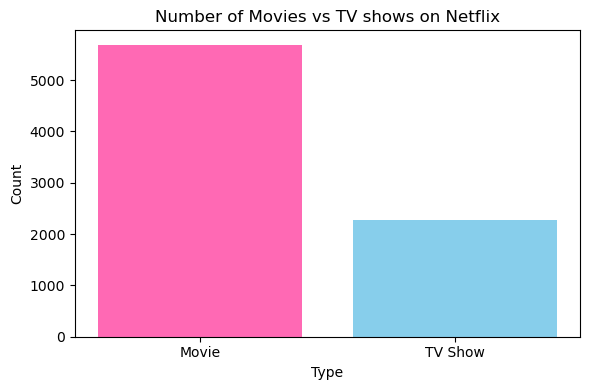

In [10]:
# setting figure size
x = type_counts.index
y = type_counts.values


# setting size 
plt.figure(figsize = (6,4))
plt.bar(x,y,color = ["hotpink","skyblue"])

plt.title("Number of Movies vs TV shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Count")

plt.tight_layout()


# saving the figure 

plt.savefig("movies vs tv shows.png")

plt.show()

### Pie chart : To see the distribution of ratings on netflix

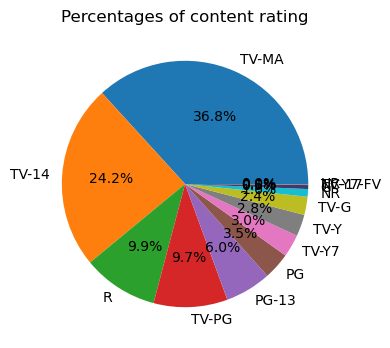

In [12]:
# figure size 
plt.figure(figsize=(4,4))

rating_count = df["rating"].value_counts()
rating_count



plt.pie(rating_count.values,labels = rating_count.index,colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", "#393b79", "#637939", "#8c6d31", "#843c39"], autopct = "%1.1f%%")


plt.title("Percentages of content rating")
plt.savefig("PieChart_content_rating.png")
plt.show()

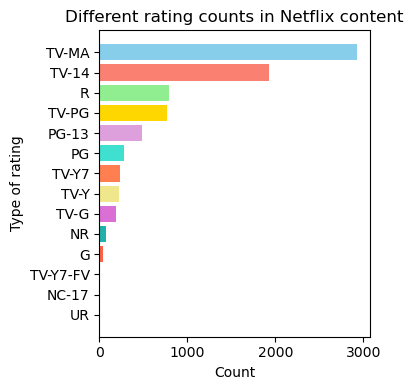

In [13]:
# since pie chart is looking cluttered , whenever the categories are in larger number , more than 6-8, it is better to use bar chart for better readability
plt.figure(figsize=(4,4))

plt.barh(rating_count.index,rating_count.values,color = ["skyblue", "salmon", "lightgreen", "gold", "plum", "turquoise", "coral", "khaki", "orchid", "lightseagreen", "tomato", "wheat", "steelblue", "palevioletred"])

plt.gca().invert_yaxis()

plt.title("Different rating counts in Netflix content")
plt.xlabel("Count")
plt.ylabel("Type of rating")

plt.savefig("BarChart_content_rating.png",bbox_inches = "tight")
plt.tight_layout()
plt.show()

### Movie Duration distribution using Histogram

In [57]:
# cleaning first

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [58]:
bool_array = df["type"] == "Movie"
movies_df = df[bool_array]

In [59]:
movies_series = movies_df["duration"].str.replace("min","")

In [60]:
movies_series

0        90 
7       125 
9       104 
12      127 
24      166 
        ... 
8801     96 
8802    158 
8804     88 
8805     88 
8806    111 
Name: duration, Length: 5687, dtype: str

In [61]:
movies_series = movies_series.astype(int)

In [62]:
movies_series

0        90
7       125
9       104
12      127
24      166
       ... 
8801     96
8802    158
8804     88
8805     88
8806    111
Name: duration, Length: 5687, dtype: int64

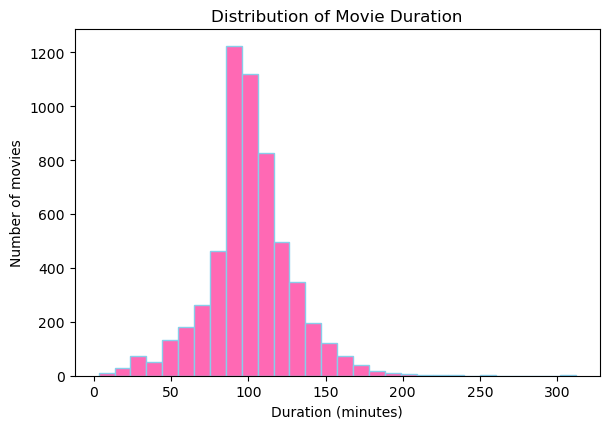

In [81]:
# now move to the visualization part

plt.figure(figsize=(6,4))

plt.hist(movies_series.values,bins = 30, color = "hotpink",edgecolor = "skyblue")
plt.tight_layout()
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of movies")



plt.savefig("movie duration histogram.png",bbox_inches = "tight")

plt.show()



### Scatter Plots : Release year vs number of shows

In [86]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...


In [87]:
bool_array = df["type"] == "TV Show"

In [118]:
series = df[bool_array]["release_year"].value_counts()
series

release_year
2020    391
2019    348
2018    325
2017    236
2021    214
2016    200
2015    139
2014     81
2013     57
2012     55
2011     39
2010     31
2009     30
2008     20
2006     14
2005     13
2007     13
2003      9
2004      8
1999      7
2002      6
2001      5
1993      4
1997      4
1998      4
2000      4
1992      3
1990      3
1986      2
1995      2
1988      2
1996      2
1994      1
1945      1
1972      1
1974      1
1977      1
1979      1
1981      1
1946      1
1985      1
1967      1
1989      1
1963      1
Name: count, dtype: int64

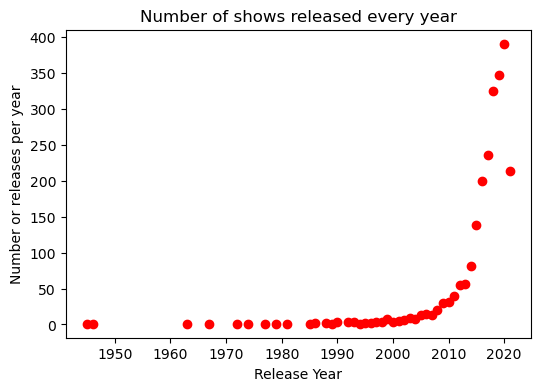

In [122]:
# now scatter plot

plt.figure(figsize=(6,4))
x = series.index
y = series.values

plt.scatter(x,y,color = "red",marker = "o")
plt.xlabel("Release Year")
plt.ylabel("Number or releases per year")
plt.title("Number of shows released every year")

plt.savefig("Shows released per year")
plt.show()

### Top ten countries with most number of TV Shows

In [137]:
bool_array = df["type"] == "TV Show"
country_series = df[bool_array]["country"]

In [139]:
country_series.value_counts().head(10)

country
United States     760
United Kingdom    213
Japan             168
South Korea       158
India              79
Taiwan             68
Canada             59
France             49
Spain              48
Australia          47
Name: count, dtype: int64

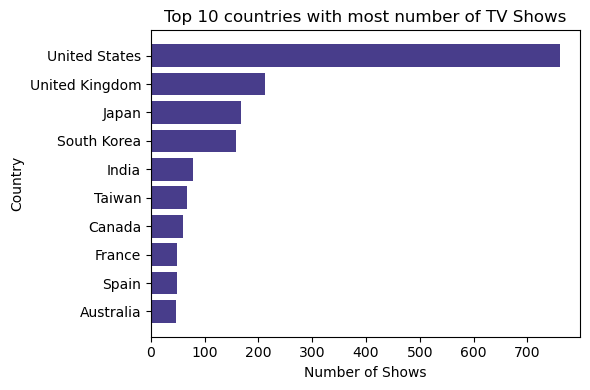

In [194]:
# barh graph for visualization
plt.figure(figsize=(6,4))

bars = country_series.value_counts().head(10).values
categories = country_series.value_counts().head(10).index

plt.barh(categories,bars,color = "darkslateblue")

# to make the bars in ascending order on graph
plt.gca().invert_yaxis()
plt.title("Top 10 countries with most number of TV Shows")
plt.xlabel("Number of Shows")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig("Countries with most shows (barh)",bbox_inches = "tight")

plt.show()